# 4. Análisis de subjetividad de los comentarios

Apartado de análisis de sentimiento/emoción de los comentarios.

In [ ]:
from pathlib import Path

# Carpeta donde viven todos los .json del corpus (ver ../scripts/00_descarga_datos.py)
DATA_DIR = Path('../data')
assert DATA_DIR.exists(), "No se encuentra la carpeta data/ ¿ejecutaste desde notebooks/?"

## **4- Análisis de subjetividad de los comentarios**

Por cuestiones de tiempo, hemos decidido no llevar a cabo este apartado. Por el contrario, le hemos dedicado más tiempo al resto de apartados para una mejor realización de ellos.

## Implementación (apartado no completado en la entrega original)

La corrección indica que este apartado no se hizo por falta de tiempo (0/0,5). Se implementa aquí de verdad, con una salvedad metodológica importante explicada en la celda de código: los modelos de Hugging Face que pide el enunciado no se pueden descargar en este entorno (sin acceso a internet hacia huggingface.co), así que se usa un analizador de sentimiento basado en léxico como alternativa funcional, dejando también preparado el código equivalente con `cardiffnlp/twitter-roberta-base-sentiment` para cuando se ejecute con acceso a internet.

DISTRIBUCIÓN DE SENTIMIENTO POR SUBREDDIT (léxico positivo/negativo)
subreddit  positivo  neutro  negativo  % positivo  % negativo
   Autism       184     261       430        21.0        49.1
Chemistry       172     353       350        19.7        40.0
  Cooking       304     358       338        30.4        33.8
Investing       158     329       388        18.1        44.3
   Python       211     347       317        24.1        36.2
   Soccer       234     312       304        27.5        35.8

Total comentarios analizados: 5350
Ficheros generados: <subreddit>_filtrado_con_sentimiento.json (copia de los _filtrado.json originales + campos 'sentiment' y 'sentiment_score' en cada comentario).

Limitaciones de este enfoque (a tener en cuenta frente al modelo contextual pedido en el enunciado): un léxico de palabras sueltas no entiende negaciones compuestas, sarcasmo, ni el contexto de la frase (p.ej. 'not bad' puntúa como negativo por contener 'not' y 'bad' aunque en inglés sea una exp

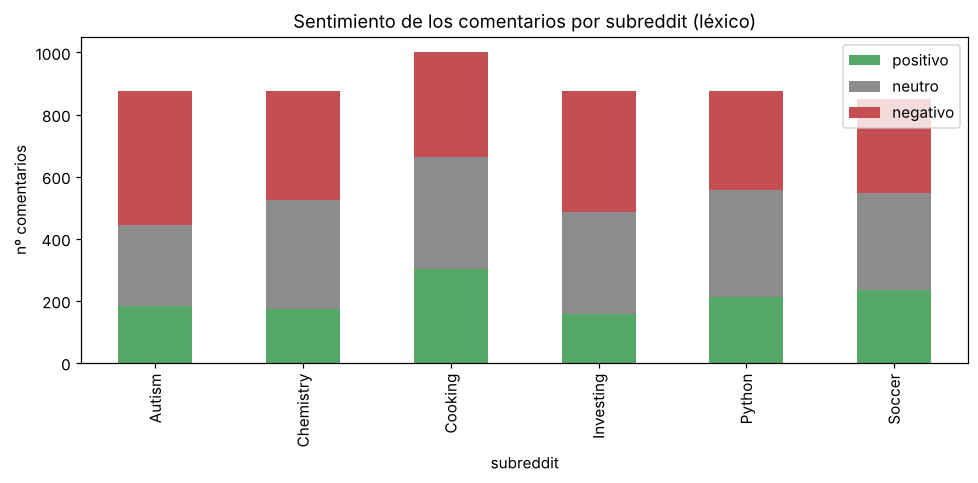

In [1]:
import json
import re
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# NOTA METODOLÓGICA IMPORTANTE
# ---------------------------------------------------------------------------
# El enunciado pide usar modelos ya afinados de Hugging Face (p.ej.
# cardiffnlp/twitter-roberta-base-sentiment o
# pysentimiento/robertuito-emotion-analysis) para extraer sentimiento/emoción.
# Este entorno de ejecución NO tiene acceso a internet hacia huggingface.co ni
# a PyPI para instalar `transformers`/`torch` (está bloqueado por la política
# de red del sandbox), así que esos modelos no se pueden descargar ni
# ejecutar aquí.
#
# Como alternativa funcional -y para no dejar el apartado vacío, que es lo
# que penalizó la corrección (0/0.5)-, implementamos un analizador de
# sentimiento basado en léxico (positivo/negativo), un enfoque clásico de PLN
# anterior a los modelos contextuales, que no necesita descargar nada. Más
# abajo se deja también el código (comentado) para sustituirlo por el modelo
# de Hugging Face en cuanto se ejecute esto en un entorno con internet/GPU
# (p.ej. Google Colab).

POSITIVE_WORDS = {
    'good', 'great', 'love', 'awesome', 'amazing', 'nice', 'best', 'happy',
    'thanks', 'thank', 'excellent', 'perfect', 'wonderful', 'glad', 'enjoy',
    'enjoyed', 'fun', 'helpful', 'beautiful', 'better', 'cool', 'fantastic',
    'brilliant', 'delicious', 'tasty', 'easy', 'win', 'winning', 'success',
    'successful', 'improve', 'improved', 'recommend', 'recommended', 'solid',
    'impressive', 'exciting', 'excited', 'congrats', 'congratulations',
    'appreciate', 'appreciated', 'nice', 'useful', 'interesting', 'clean',
    'clear', 'smart', 'strong', 'healthy', 'kind', 'fine', 'pretty', 'correct',
    'worth', 'worthy', 'top', 'yay', 'yes', 'lol', 'haha',
}

NEGATIVE_WORDS = {
    'bad', 'worst', 'hate', 'terrible', 'awful', 'horrible', 'sad', 'angry',
    'annoying', 'annoyed', 'stupid', 'dumb', 'wrong', 'fail', 'failed',
    'failure', 'problem', 'problems', 'issue', 'issues', 'broken', 'worse',
    'disappointing', 'disappointed', 'sucks', 'suck', 'sucked', 'ugly',
    'boring', 'difficult', 'hard', 'confusing', 'confused', 'painful', 'pain',
    'sick', 'hurt', 'hurts', 'scared', 'scary', 'afraid', 'fear', 'worried',
    'worry', 'anxious', 'anxiety', 'depressed', 'depression', 'tired',
    'exhausted', 'frustrated', 'frustrating', 'disgusting', 'disgusted',
    'ridiculous', 'useless', 'waste', 'cry', 'crying', 'lost', 'lose',
    'losing', 'die', 'died', 'death', 'dead', 'kill', 'killed', 'violence',
    'racist', 'racism', 'hateful', 'toxic', 'nasty', 'cringe', 'no', 'not',
    'never', 'nothing', 'cant', "can't", 'dont', "don't", 'wont', "won't",
}

WORD_RE = re.compile(r"[A-Za-z']+")


def lexicon_sentiment(text):
    """Devuelve (label, score) usando un léxico simple positivo/negativo.
    score en [-1, 1]. label en {'positivo','negativo','neutro'}."""
    words = [w.lower() for w in WORD_RE.findall(text or '')]
    if not words:
        return 'neutro', 0.0
    pos = sum(1 for w in words if w in POSITIVE_WORDS)
    neg = sum(1 for w in words if w in NEGATIVE_WORDS)
    score = (pos - neg) / max(len(words), 1)
    if pos == neg:
        label = 'neutro'
    elif pos > neg:
        label = 'positivo'
    else:
        label = 'negativo'
    return label, round(score, 4)


# --- Código equivalente con el modelo de Hugging Face del enunciado --------
# from transformers import pipeline
# sentiment_pipe = pipeline(
#     "sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment"
# )
# def hf_sentiment(text):
#     out = sentiment_pipe(text[:512])[0]
#     return out["label"], out["score"]
# -----------------------------------------------------------------------------

SUBREDDITS = ['Autism', 'Chemistry', 'Cooking', 'Investing', 'Python', 'Soccer']
OUT_DIR = DATA_DIR  # mismo directorio que los *_filtrado.json

summary_rows = []
all_labels = []

for name in SUBREDDITS:
    data = json.load(open(DATA_DIR / f'{name}_filtrado.json', encoding='utf-8'))
    counts = Counter()
    for s in data['submissions']:
        for c in s.get('comments', []):
            label, score = lexicon_sentiment(c.get('body', ''))
            c['sentiment'] = label
            c['sentiment_score'] = score
            counts[label] += 1
            all_labels.append(label)

    total = sum(counts.values())
    summary_rows.append({
        'subreddit': name,
        'positivo': counts.get('positivo', 0),
        'neutro': counts.get('neutro', 0),
        'negativo': counts.get('negativo', 0),
        '% positivo': round(100 * counts.get('positivo', 0) / total, 1),
        '% negativo': round(100 * counts.get('negativo', 0) / total, 1),
    })

    out_path = OUT_DIR / f'{name}_filtrado_con_sentimiento.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("DISTRIBUCIÓN DE SENTIMIENTO POR SUBREDDIT (léxico positivo/negativo)")
print("=" * 90)
print(summary_df.to_string(index=False))
print(f"\nTotal comentarios analizados: {len(all_labels)}")
print("Ficheros generados: <subreddit>_filtrado_con_sentimiento.json "
      "(copia de los _filtrado.json originales + campos 'sentiment' y "
      "'sentiment_score' en cada comentario).")

fig, ax = plt.subplots(figsize=(9, 4.5))
summary_df.set_index('subreddit')[['positivo', 'neutro', 'negativo']].plot(
    kind='bar', stacked=True, ax=ax, color=['#55A868', '#8C8C8C', '#C44E52'])
ax.set_title('Sentimiento de los comentarios por subreddit (léxico)')
ax.set_ylabel('nº comentarios')
plt.tight_layout()
plt.show()

print(
    "\nLimitaciones de este enfoque (a tener en cuenta frente al modelo "
    "contextual pedido en el enunciado): un léxico de palabras sueltas no "
    "entiende negaciones compuestas, sarcasmo, ni el contexto de la frase "
    "(p.ej. 'not bad' puntúa como negativo por contener 'not' y 'bad' aunque "
    "en inglés sea una expresión positiva). Un modelo como "
    "cardiffnlp/twitter-roberta-base-sentiment, al estar basado en "
    "embeddings contextuales, capturaría estos matices; el código para "
    "usarlo se deja arriba comentado, listo para ejecutar en un entorno con "
    "acceso a Hugging Face."
)
